# MedGemma — Training + Evaluation (Colab GPU)

Run on a **GPU runtime**. This notebook has two sections:

1. **Training** — loads the `DatasetDict` from the preprocessing notebook,
   fine-tunes MedGemma (QLoRA) on the **train** split with live augmentation,
   tracks `eval_loss` on **validation**, and pushes the LoRA adapter to the Hub.
   Images (pre-made PNG / TIFF) are loaded on the fly.
2. **Evaluation** — reuses the just-trained model in memory and runs a richer
   evaluation on the held-out **test** split:
   - **Prediction probabilities for BI-RADS and ACR density** via closed-set
     ("teacher-forced") scoring — a confidence for each field.
   - **Imbalance-aware metrics**: macro-F1, balanced accuracy, and bootstrap 95%
     confidence intervals, so rare BI-RADS classes are not hidden by the majority.
   - **Calibration**: Expected Calibration Error (ECE) + a reliability table,
     with optional temperature scaling fit on the validation split.

In [1]:
!pip install -q -U bitsandbytes evaluate rouge-score trl peft

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 51.8 MB/s eta 0:00:00


In [ ]:
import json
import re
from collections import Counter
from pathlib import Path

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from datasets import load_from_disk
from datasets.formatting.formatting import LazyBatch
from huggingface_hub import login
from peft import LoraConfig
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from torchvision import transforms as T
from tqdm import tqdm
from transformers import (
    BitsAndBytesConfig,
    EarlyStoppingCallback,
    Gemma3ForConditionalGeneration,
    Gemma3Processor,
)
from trl import SFTConfig, SFTTrainer

SEED = 2
MAX_NEW_TOKENS = 1024

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
ROOT_DIR = Path("/content/drive/MyDrive/MedGemma2026/main")
DATA_DIR = ROOT_DIR / "data"
CONFIG_DIR = ROOT_DIR / "config"
SPLIT_DIR = DATA_DIR / "split"
RESULTS_DIR = ROOT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
from google.colab import userdata

login(userdata.get("HF_TOKEN"))

## Data, prompts & transforms

In [6]:
data = load_from_disk(str(SPLIT_DIR))
print({k: len(v) for k, v in data.items()})
data

{'train': 3670, 'validation': 1000, 'test': 1000}


DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'text', 'image', 'birads', 'birads_strata', 'acr_density', 'augment'],
        num_rows: 3670
    })
    validation: Dataset({
        features: ['id', 'source', 'text', 'image', 'birads', 'birads_strata', 'acr_density'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['id', 'source', 'text', 'image', 'birads', 'birads_strata', 'acr_density'],
        num_rows: 1000
    })
})

In [7]:
def load_prompts(file_path: Path) -> dict:
    if not file_path.exists():
        raise FileNotFoundError(f"Prompt config not found: {file_path}")

    with open(file_path) as stream:
        return yaml.safe_load(stream)


prompts = load_prompts(CONFIG_DIR / "prompts-cot-zeroshot.yaml")
mammography_analysis_prompt = prompts["zero_shot"]
mammography_analysis_prompt

{'system': 'You are a board-certified breast radiologist with deep, up-to-date knowledge\nof the ACR BI-RADS (Breast Imaging-Reporting and Data System) lexicon and\nextensive experience interpreting screening and diagnostic mammograms. You\nare meticulous and always produce clear, concise, clinically actionable\nreports. You are given a single 2D mammogram view; analyze it and return a\nstructured report.\n',
 'user_instruction': 'Analyze the provided 2D mammogram view.\n\nFirst, identify the breast density using the ACR classification:\n- ACR A: The breasts are almost entirely fatty.\n- ACR B: There are scattered areas of fibroglandular density.\n- ACR C: The breasts are heterogeneously dense, which may obscure small masses.\n- ACR D: The breasts are extremely dense, which lowers the sensitivity of mammography.\n\nThen describe any abnormalities you notice. Findings include Mass,\nSuspicious Calcification, Architectural Distortion, Suspicious Lymph Node,\nNipple Retraction, Skin Retra

In [8]:
def load_and_resize_image(image_path: str, max_size: int = 512) -> Image.Image:
    image = Image.open(str(image_path)).convert("RGB")
    image.thumbnail((max_size, max_size), resample=Image.Resampling.LANCZOS)
    return image

In [9]:
# Live augmentation for DUPLICATE (oversampled) train records only -- the original
# copy of each case is kept clean; val/test use the plain transform below.
# Flip is laterality-safe because the reports don't mention left/right; small
# translate + scale add positional/size variety; rotation is intentionally
# omitted since mammograms are anatomically aligned.
TRAIN_AUGMENT = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
])


def transform_and_format_train_data(batch: LazyBatch) -> LazyBatch:
    # `augment` is set per-record by the split notebook.
    images = [load_and_resize_image(image_path) for image_path in batch["image"]]
    augment_flags = batch.get("augment", [True] * len(images))
    batch["image"] = [
        TRAIN_AUGMENT(img) if aug else img for img, aug in zip(images, augment_flags)
    ]

    batch["messages"] = [
        [
            {
                "role": "system",
                "content": [
                    {"type": "text", "text": mammography_analysis_prompt["system"]}
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": mammography_analysis_prompt["user_instruction"],
                    },
                ],
            },
            {"role": "assistant", "content": [{"type": "text", "text": text}]},
        ]
        for text in batch["text"]
    ]

    return batch


data["train"].set_transform(transform_and_format_train_data)

In [10]:
def transform_and_format_eval_data(batch: LazyBatch) -> LazyBatch:
    batch["image"] = [load_and_resize_image(image_path) for image_path in batch["image"]]

    batch["messages"] = [
        [
            {
                "role": "system",
                "content": [
                    {"type": "text", "text": mammography_analysis_prompt["system"]}
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": mammography_analysis_prompt["user_instruction"],
                    },
                ],
            },
        ]
        for _ in batch["text"]
    ]

    return batch


def transform_and_format_val_data(batch: LazyBatch) -> LazyBatch:
    # Validation LOSS transform: includes the assistant report (and no
    # augmentation) so eval_loss is computed over report tokens -- a valid,
    # train-comparable early-stopping signal. TEST uses the generation transform.
    batch["image"] = [load_and_resize_image(image_path) for image_path in batch["image"]]

    batch["messages"] = [
        [
            {
                "role": "system",
                "content": [
                    {"type": "text", "text": mammography_analysis_prompt["system"]}
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": mammography_analysis_prompt["user_instruction"],
                    },
                ],
            },
            {"role": "assistant", "content": [{"type": "text", "text": text}]},
        ]
        for text in batch["text"]
    ]

    return batch


# Validation is scored by LOSS during training (needs the assistant report);
# test is scored by GENERATION in Section 2 (prompt only).
data["validation"].set_transform(transform_and_format_val_data)
data["test"].set_transform(transform_and_format_eval_data)

In [11]:
def extract_birads_level(text: str) -> str:
    match = re.search(r"BI[-\s]?RADS:\s*(.+?)(?:\n|$)", text, re.IGNORECASE)
    return (
        re.sub(r"\s*,\s*", " and ", match.group(1).strip().lower())
        if match
        else "unknown"
    )


def extract_acr_density(text: str) -> str | None:
    match = re.search(r"\(ACR[\s-]+([A-D])\s*\)", text, re.IGNORECASE)
    return match.group(1).upper() if match else None

## Section 1 · Fine-tune MedGemma (QLoRA)

Load the base model in 4-bit (NF4), attach a LoRA adapter, and fine-tune on the
**train** split while tracking `eval_loss` on **validation**. `load_best_model_at_end`
restores the best checkpoint, which the evaluation section below reuses directly.

In [12]:
model_id = "google/medgemma-1.5-4b-it"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_storage=torch.bfloat16,
)

model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto",
    quantization_config=quantization_config,
)

processor = Gemma3Processor.from_pretrained(model_id, use_fast=True)
processor.tokenizer.padding_side = "right"

config.json:   0%|          | 0.00/2.55k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

In [13]:
peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=16,
    target_modules="all-linear",
    lora_alpha=16,
    lora_dropout=0.05,
    modules_to_save=["lm_head", "embed_tokens"],
    ensure_weight_tying=True,
)

In [14]:
def collate_fn(examples: list[dict]):
    texts = []
    images = []

    for example in examples:
        images.append([example["image"]])
        texts.append(
            processor.apply_chat_template(
                example["messages"], add_generation_prompt=False, tokenize=False
            ).strip()
        )

    batch = processor(images=images, text=texts, return_tensors="pt", padding=True)

    labels = batch["input_ids"].clone()

    image_token_id = [
        processor.tokenizer.convert_tokens_to_ids(
            processor.tokenizer.special_tokens_map["boi_token"]
        )
    ]

    labels[
        (labels == processor.tokenizer.pad_token_id)
        | (labels == image_token_id)
        | (labels == 262144)
    ] = -100

    batch["labels"] = labels
    return batch

In [15]:
HUB_MODEL_ID = "medgemma-1.5-4b-it-sft-lora-dmid-vindr"

args = SFTConfig(
    output_dir=HUB_MODEL_ID,
    eval_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=32,
    learning_rate=2e-4,
    max_grad_norm=0.3,
    num_train_epochs=10,
    lr_scheduler_type="linear",
    warmup_steps=0.03,
    logging_steps=50,
    save_strategy="steps",
    bf16=True,
    eval_steps=50,
    remove_unused_columns=False,
    label_names=["labels"],
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    push_to_hub=True,
    hub_strategy="end",
    hub_model_id=HUB_MODEL_ID,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataset_kwargs={"skip_prepare_dataset": True},
)

trainer = SFTTrainer(
    model,
    args=args,
    data_collator=collate_fn,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    processing_class=processor,
    peft_config=peft_config,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.
[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,0.376785,0.013100,0.012483,9567799.000000,0.994316
100,0.015172,0.013827,0.009160,19134101.000000,0.994747
150,0.009517,0.014531,0.008613,28568360.000000,0.994793


TrainOutput(global_step=150, training_loss=0.13382463256518046, metrics={'train_runtime': 23937.0283, 'train_samples_per_second': 1.533, 'train_steps_per_second': 0.006, 'total_flos': 6.57022105661208e+17, 'train_loss': 0.13382463256518046, 'epoch': 10.0})

Best epoch: 3.3 | Best eval loss: 0.0131
Suggested num_train_epochs = 3


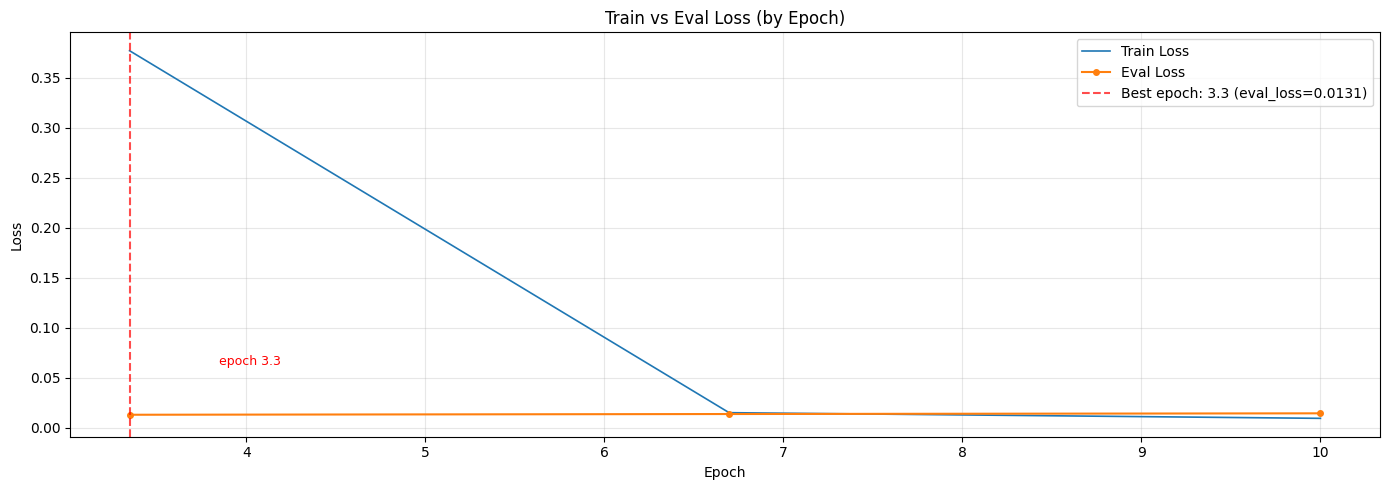

In [16]:
log_history = trainer.state.log_history

train_epochs, train_losses = [], []
eval_epochs, eval_losses = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_epochs, train_losses, linewidth=1.2, color="tab:blue", label="Train Loss")
ax.plot(
    eval_epochs,
    eval_losses,
    linewidth=1.5,
    color="tab:orange",
    marker="o",
    markersize=4,
    label="Eval Loss",
)

if eval_losses:
    best_idx = eval_losses.index(min(eval_losses))
    best_epoch = eval_epochs[best_idx]
    best_loss = eval_losses[best_idx]
    ax.axvline(
        best_epoch,
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"Best epoch: {best_epoch:.1f} (eval_loss={best_loss:.4f})",
    )
    ax.annotate(
        f"epoch {best_epoch:.1f}",
        xy=(best_epoch, best_loss),
        xytext=(best_epoch + 0.5, best_loss + 0.05),
        fontsize=9,
        color="red",
    )
    print(f"Best epoch: {best_epoch:.1f} | Best eval loss: {best_loss:.4f}")
    print(f"Suggested num_train_epochs = {round(best_epoch)}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Train vs Eval Loss (by Epoch)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curve_by_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2 · Evaluation on the held-out TEST split

Reuses the model fine-tuned above directly from memory (`trainer.model` — the
best checkpoint loaded by `load_best_model_at_end=True`), so there is no reload
from the Hub. The scoring below adds closed-set probabilities, imbalance-aware
metrics, and calibration on top of plain generation.

In [17]:
model = trainer.model
model.eval()
tokenizer = processor.tokenizer
print("Using the in-memory fine-tuned model for evaluation.")

Using the in-memory fine-tuned model for evaluation.


### Prediction probabilities (closed-set scoring)

For each report the model writes, we read the model's own logits at the exact
position where it commits to the ACR letter and the BI-RADS category, and take a
softmax over **only the valid choices** ({A, B, C, D} for density; {1..5} for
BI-RADS). That yields a probability distribution over the real options — e.g.
`ACR = {A: 0.02, B: 0.71, C: 0.26, D: 0.01}` → confidence 0.71 in "B".

Because decoding is greedy (`do_sample=False`), these logits are the model's true
next-token scores. We capture them with `output_scores=True` and locate the
decision token by aligning a cumulative decode of the generated tokens with the
report text.

In [18]:
ACR_CHOICES = ["A", "B", "C", "D"]
BIRADS_CHOICES = ["1", "2", "3", "4", "5"]


def _cumulative_spans(token_ids):
    """Char [start, end) span each generated token occupies in the decoded text.
    Cumulative decode so SentencePiece spacing is handled correctly."""
    spans, prev = [], ""
    for k in range(len(token_ids)):
        cur = tokenizer.decode(token_ids[: k + 1], skip_special_tokens=True)
        spans.append((len(prev), len(cur)))
        prev = cur
    return spans, prev


def _step_for_char(spans, char_idx):
    for t, (s, e) in enumerate(spans):
        if s <= char_idx < e:
            return t
    return None


def _candidate_ids(choices, chosen_char, chosen_id):
    """Map each choice to a single token id, matched to the in-context surface
    form (with / without a leading space) the model actually used."""
    for prefix in (" ", ""):
        ids = {c: tokenizer.encode(prefix + c, add_special_tokens=False) for c in choices}
        if all(len(v) == 1 for v in ids.values()) and ids.get(chosen_char, [None])[0] == chosen_id:
            return {c: v[0] for c, v in ids.items()}, True
    ids = {c: tokenizer.encode(c, add_special_tokens=False) for c in choices}
    return {c: (v[0] if len(v) == 1 else None) for c, v in ids.items()}, False


def _closed_set_prob(scores, char_idx, spans, gen_ids, choices):
    t = _step_for_char(spans, char_idx)
    if t is None or t >= len(scores):
        return None
    step_logits = scores[t]
    chosen_id = int(gen_ids[t])
    chosen_char = tokenizer.decode([chosen_id]).strip()
    cand, form_ok = _candidate_ids(choices, chosen_char, chosen_id)
    ids = [cand[c] for c in choices]
    if any(j is None for j in ids):
        return None
    logits = step_logits[ids].float()
    probs = torch.softmax(logits, dim=-1)
    pred = choices[int(torch.argmax(probs))]
    return {
        "pred": pred,
        "conf": float(probs[choices.index(pred)]),
        "dist": dict(zip(choices, [float(p) for p in probs])),
        "logits": [float(x) for x in logits],
        "form_ok": form_ok,
    }


def score_report(generated_ids, scores):
    """Closed-set probabilities for ACR and BI-RADS from one generation.
    generated_ids: 1-D tensor of generated tokens (prompt stripped).
    scores: list of per-step logit vectors, len == len(generated_ids)."""
    ids_list = generated_ids.tolist()
    spans, text = _cumulative_spans(ids_list)
    out = {"text": text, "acr": None, "birads": None}
    m = re.search(r"\(ACR[\s-]+([A-D])\s*\)", text, re.IGNORECASE)
    if m:
        out["acr"] = _closed_set_prob(scores, m.start(1), spans, generated_ids, ACR_CHOICES)
    m = re.search(r"BI[-\s]?RADS:\s*([1-5])", text, re.IGNORECASE)
    if m:
        out["birads"] = _closed_set_prob(scores, m.start(1), spans, generated_ids, BIRADS_CHOICES)
    return out

### Generate on the held-out test split

In [19]:
def run_eval(split, desc):
    """Generate greedily over a split and score each report. Returns
    (predictions, references, rows); rows[i] holds the closed-set ACR / BI-RADS
    probability dicts."""
    predictions, references, rows = [], [], []
    image_paths = split.data.column("image").to_pylist()   # raw paths (bypasses the transform)
    for i in tqdm(range(len(split)), desc=desc):
        sample = split[i]
        inputs = processor(
            images=[[sample["image"]]],
            text=[
                processor.apply_chat_template(
                    sample["messages"], add_generation_prompt=True, tokenize=False
                ).strip()
            ],
            return_tensors="pt",
            padding=True,
        ).to(model.device)
        in_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                return_dict_in_generate=True,
                output_scores=True,
            )

        gen_ids = out.sequences[0, in_len:].detach().cpu()
        scores = [s[0].detach().float().cpu() for s in out.scores]  # free GPU after
        del out
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        sc = score_report(gen_ids, scores)
        del scores

        predictions.append(sc["text"])
        references.append(sample["text"])
        rows.append({"i": i, "image_id": Path(image_paths[i]).stem,
                     "image_path": image_paths[i], "text": sc["text"],
                     "ref": sample["text"], "acr": sc["acr"], "birads": sc["birads"]})
    return predictions, references, rows


predictions, references, rows = run_eval(data["test"], "Generating + scoring (test)")

with open("eval_output.txt", "w") as f:
    for r in rows:
        f.write(f"\n--- Sample {r['i']}  [{r['image_id']}]  {r['image_path']} ---\n")
        f.write(f"Original report: {r['ref']}\n")
        f.write(f"Generated report: {r['text']}\n")
        if r["birads"]:
            f.write(f"BI-RADS pred={r['birads']['pred']} conf={r['birads']['conf']:.3f} "
                    f"dist={r['birads']['dist']}\n")
        if r["acr"]:
            f.write(f"ACR pred={r['acr']['pred']} conf={r['acr']['conf']:.3f} "
                    f"dist={r['acr']['dist']}\n")

bir_cov = sum(r["birads"] is not None for r in rows)
acr_cov = sum(r["acr"] is not None for r in rows)
print(f"\nScored {len(rows)} reports. Probability coverage: "
      f"BI-RADS {bir_cov}/{len(rows)}, ACR {acr_cov}/{len(rows)}")

Generating + scoring (test):   0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Generating + scoring (test): 100%|██████████| 1000/1000 [2:25:39<00:00,  8.74s/it]


Scored 1000 reports. Probability coverage: BI-RADS 1000/1000, ACR 1000/1000


## Imbalance-aware metrics (macro-F1, balanced accuracy, 95% CIs)

In [20]:
rng = np.random.default_rng(SEED)


def bootstrap_ci(values, n=1000, alpha=0.05):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return float("nan"), float("nan"), float("nan")
    idx = rng.integers(0, len(values), size=(n, len(values)))
    boot = values[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)


def bootstrap_metric(y_true, y_pred, metric, n=1000, alpha=0.05):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    point = float(metric(y_true, y_pred))
    boot = []
    for _ in range(n):
        ii = rng.integers(0, len(y_true), size=len(y_true))
        boot.append(metric(y_true[ii], y_pred[ii]))
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return point, float(lo), float(hi)


valid_pairs = [(p, r) for p, r in zip(predictions, references) if p.strip()]
valid_preds, valid_refs = (list(x) for x in zip(*valid_pairs)) if valid_pairs else ([], [])
print(f"Computing metrics on {len(valid_preds)}/{len(predictions)} non-empty predictions\n")

# Text metrics (ROUGE-L CI from per-sample scores)
rouge = evaluate.load("rouge")
rouge_per = rouge.compute(predictions=valid_preds, references=valid_refs, use_aggregator=False)
rougeL_mean, rougeL_lo, rougeL_hi = bootstrap_ci(rouge_per["rougeL"])
rouge_agg = {k: float(np.mean(v)) for k, v in rouge_per.items()}

meteor = evaluate.load("meteor")
meteor_score = meteor.compute(predictions=valid_preds, references=valid_refs)["meteor"]

bleu = evaluate.load("bleu")
bleu_results = {}
for order in range(1, 5):
    try:
        bleu_results[f"bleu_{order}"] = bleu.compute(
            predictions=valid_preds, references=valid_refs, max_order=order
        )["bleu"]
    except ZeroDivisionError:
        bleu_results[f"bleu_{order}"] = 0.0


def word_level_f1(prediction: str, reference: str) -> dict:
    pred_tokens = prediction.lower().split()
    ref_tokens = reference.lower().split()
    common = sum((Counter(pred_tokens) & Counter(ref_tokens)).values())
    if common == 0:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}
    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)
    f1 = 2 * precision * recall / (precision + recall)
    return {"precision": precision, "recall": recall, "f1": f1}


wf1_scores = [word_level_f1(p, r) for p, r in zip(valid_preds, valid_refs)]
avg_wf1 = (
    {k: sum(s[k] for s in wf1_scores) / len(wf1_scores) for k in ("precision", "recall", "f1")}
    if wf1_scores
    else {"precision": 0.0, "recall": 0.0, "f1": 0.0}
)

# BI-RADS / ACR classification
true_birads = [extract_birads_level(r) for r in references]
pred_birads = [extract_birads_level(p) for p in predictions]
true_acr = [extract_acr_density(r) or "unknown" for r in references]
pred_acr = [extract_acr_density(p) or "unknown" for p in predictions]


def macro_f1(yt, yp):
    return f1_score(yt, yp, average="macro", zero_division=0)


bir_acc = bootstrap_metric(true_birads, pred_birads, accuracy_score)
bir_macro = bootstrap_metric(true_birads, pred_birads, macro_f1)
bir_bal = bootstrap_metric(true_birads, pred_birads, balanced_accuracy_score)
acr_acc = bootstrap_metric(true_acr, pred_acr, accuracy_score)
acr_macro = bootstrap_metric(true_acr, pred_acr, macro_f1)
acr_bal = bootstrap_metric(true_acr, pred_acr, balanced_accuracy_score)


def fmt(ci):
    p, lo, hi = ci
    return f"{p:.4f}  [95% CI {lo:.4f}, {hi:.4f}]"


print("TEXT GENERATION")
print("-" * 60)
for k, v in rouge_agg.items():
    print(f"{k:<12s}: {v:.4f}")
print(f"{'rougeL (CI)':<12s}: {fmt((rougeL_mean, rougeL_lo, rougeL_hi))}")
print(f"{'meteor':<12s}: {meteor_score:.4f}")
print("--- BLEU ---")
for _k, _v in bleu_results.items():
    print(f"{_k:<12s}: {_v:.4f}")
print("--- Word-Level F1 ---")
for _k in ("precision", "recall", "f1"):
    print(f"{'wf1_' + _k:<12s}: {avg_wf1[_k]:.4f}")

print("\nBI-RADS (imbalance-aware)")
print("-" * 60)
print(f"accuracy          : {fmt(bir_acc)}")
print(f"macro-F1          : {fmt(bir_macro)}")
print(f"balanced accuracy : {fmt(bir_bal)}")
print("\nPer-class:\n" + classification_report(true_birads, pred_birads, zero_division=0))

print("ACR density (imbalance-aware)")
print("-" * 60)
print(f"accuracy          : {fmt(acr_acc)}")
print(f"macro-F1          : {fmt(acr_macro)}")
print(f"balanced accuracy : {fmt(acr_bal)}")
print("\nPer-class:\n" + classification_report(true_acr, pred_acr, zero_division=0))

Computing metrics on 1000/1000 non-empty predictions



[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics

TEXT GENERATION
------------------------------------------------------------
rouge1      : 0.8048
rouge2      : 0.7064
rougeL      : 0.8024
rougeLsum   : 0.8043
rougeL (CI) : 0.8024  [95% CI 0.7916, 0.8141]
meteor      : 0.8388
--- BLEU ---
bleu_1      : 0.8300
bleu_2      : 0.7870
bleu_3      : 0.7497
bleu_4      : 0.7166
--- Word-Level F1 ---
wf1_precision: 0.7995
wf1_recall  : 0.8003
wf1_f1      : 0.7970

BI-RADS (imbalance-aware)
------------------------------------------------------------
accuracy          : 0.4370  [95% CI 0.4070, 0.4690]
macro-F1          : 0.1893  [95% CI 0.1520, 0.2655]
balanced accuracy : 0.2312  [95% CI 0.1843, 0.3209]

Per-class:
              precision    recall  f1-score   support

           1       0.53      0.65      0.58       336
           2       0.49      0.43      0.46       335
           3       0.30      0.21      0.25       158
     3 and 4       0.00      0.00      0.00         2
    3 and 4a       0.00      0.00      0.00         0
    3 an

## Calibration (ECE + reliability)

Do the confidences mean what they say? ECE compares confidence to actual
accuracy within bins; 0 is perfect. BI-RADS calibration is computed for the main
category (1-5) on single-category reports (multi-category / unknown references
are excluded and counted).

In [21]:
def expected_calibration_error(confs, correct, n_bins=10):
    confs = np.asarray(confs, dtype=float)
    correct = np.asarray(correct, dtype=float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, table, n = 0.0, [], len(confs)
    for b in range(n_bins):
        lo, hi = bins[b], bins[b + 1]
        mask = (confs > lo) & (confs <= hi) if b > 0 else (confs >= lo) & (confs <= hi)
        cnt = int(mask.sum())
        if cnt == 0:
            table.append((lo, hi, 0, float("nan"), float("nan")))
            continue
        avg_conf = float(confs[mask].mean())
        acc = float(correct[mask].mean())
        ece += (cnt / n) * abs(acc - avg_conf)
        table.append((lo, hi, cnt, avg_conf, acc))
    return ece, table


def _true_label(r, field, choices):
    if field == "acr":
        true = extract_acr_density(r["ref"])
        return true if true in choices else None
    cats = re.findall(r"[1-5]", extract_birads_level(r["ref"]))
    return cats[0] if len(set(cats)) == 1 else None


def calibration_for(field, choices):
    confs, correct, excluded = [], [], 0
    for r in rows:
        scored = r[field]
        if scored is None:
            continue
        true = _true_label(r, field, choices)
        if true is None:
            excluded += 1
            continue
        confs.append(scored["conf"])
        correct.append(scored["pred"] == true)
    ece, table = expected_calibration_error(confs, correct)
    return ece, table, len(confs), excluded


for field, choices, name in [("birads", BIRADS_CHOICES, "BI-RADS"),
                             ("acr", ACR_CHOICES, "ACR density")]:
    ece, table, n_used, excluded = calibration_for(field, choices)
    print(f"\n{name}: ECE = {ece:.4f}  (n={n_used}, excluded={excluded})")
    print(f"  {'bin':<14}{'count':>7}{'avg_conf':>10}{'accuracy':>10}")
    for lo, hi, cnt, avg_conf, acc in table:
        if cnt == 0:
            continue
        print(f"  ({lo:.1f}, {hi:.1f}]{cnt:>9}{avg_conf:>10.3f}{acc:>10.3f}")


BI-RADS: ECE = 0.0383  (n=986, excluded=14)
  bin             count  avg_conf  accuracy
  (0.2, 0.3]       87     0.275     0.333
  (0.3, 0.4]      321     0.352     0.374
  (0.4, 0.5]      254     0.448     0.453
  (0.5, 0.6]      160     0.544     0.519
  (0.6, 0.7]       69     0.643     0.522
  (0.7, 0.8]       58     0.747     0.638
  (0.8, 0.9]       19     0.835     0.684
  (0.9, 1.0]       18     0.936     0.778

ACR density: ECE = 0.3440  (n=1000, excluded=0)
  bin             count  avg_conf  accuracy
  (0.9, 1.0]     1000     1.000     0.656


## Optional — temperature scaling

Raw LLM probabilities are often over-confident. Temperature scaling divides the
logits by a single learned `T` before softmax. Set the flag below to `True` to
fit `T` on the *validation* split (correct practice — never fit on test) and
report calibrated test ECE. It re-generates over validation, so it is slow;
leave it `False` to skip.

In [22]:
RUN_TEMPERATURE_SCALING = False


def fit_temperature(logit_rows, labels, choices):
    L = torch.tensor(logit_rows, dtype=torch.float)
    y = torch.tensor([choices.index(c) for c in labels], dtype=torch.long)
    best_T, best_nll = 1.0, float("inf")
    for T in torch.linspace(0.5, 5.0, 91):
        nll = torch.nn.functional.cross_entropy(L / T, y).item()
        if nll < best_nll:
            best_T, best_nll = float(T), nll
    return best_T


def collect_logits(rows_, field, choices):
    logit_rows, labels = [], []
    for r in rows_:
        scored = r[field]
        if scored is None or scored.get("logits") is None:
            continue
        true = _true_label(r, field, choices)
        if true is None:
            continue
        logit_rows.append(scored["logits"])
        labels.append(true)
    return logit_rows, labels


def ece_from_logits(logit_rows, labels, choices, T=1.0):
    L = torch.tensor(logit_rows, dtype=torch.float) / T
    probs = torch.softmax(L, dim=-1)
    conf, pred_idx = probs.max(dim=-1)
    correct = [choices[int(pi)] == lab for pi, lab in zip(pred_idx, labels)]
    return expected_calibration_error(conf.tolist(), correct)[0]


if RUN_TEMPERATURE_SCALING:
    # Temperature scaling GENERATES on val, so switch it to the prompt-only
    # (generation) transform first; the loss transform above includes the answer.
    data["validation"].set_transform(transform_and_format_eval_data)
    _, _, val_rows = run_eval(data["validation"], "Generating + scoring (val)")
    for field, choices, name in [("birads", BIRADS_CHOICES, "BI-RADS"),
                                 ("acr", ACR_CHOICES, "ACR density")]:
        vl, vlab = collect_logits(val_rows, field, choices)
        tl, tlab = collect_logits(rows, field, choices)
        T = fit_temperature(vl, vlab, choices)
        before = ece_from_logits(tl, tlab, choices, T=1.0)
        after = ece_from_logits(tl, tlab, choices, T=T)
        print(f"{name}: T={T:.2f}  test ECE {before:.4f} -> {after:.4f}")
else:
    print("Temperature scaling skipped (set RUN_TEMPERATURE_SCALING = True).")

Temperature scaling skipped (set RUN_TEMPERATURE_SCALING = True).


## Save results to Drive

In [23]:
import shutil

shutil.copy("eval_output.txt", RESULTS_DIR / "eval_output.txt")

with open(RESULTS_DIR / "eval_predictions.jsonl", "w") as f:
    for r in rows:
        f.write(json.dumps(r) + "\n")

metrics_summary = {
    "text": {
        "rouge": rouge_agg,
        "rougeL_ci": [rougeL_mean, rougeL_lo, rougeL_hi],
        "bleu": bleu_results,
        "meteor": meteor_score,
        "word_level_f1": avg_wf1,
    },
    "birads": {
        "accuracy_ci": list(bir_acc),
        "macro_f1_ci": list(bir_macro),
        "balanced_accuracy_ci": list(bir_bal),
    },
    "acr_density": {
        "accuracy_ci": list(acr_acc),
        "macro_f1_ci": list(acr_macro),
        "balanced_accuracy_ci": list(acr_bal),
    },
    "probability_coverage": {"birads": bir_cov, "acr": acr_cov, "n": len(rows)},
    "num_predictions": len(predictions),
}
with open(RESULTS_DIR / "eval_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved:")
print(f"  {RESULTS_DIR / 'eval_output.txt'}")
print(f"  {RESULTS_DIR / 'eval_predictions.jsonl'}")
print(f"  {RESULTS_DIR / 'eval_metrics.json'}")

Saved:
  /content/drive/MyDrive/MedGemma2026/main/results/eval_output.txt
  /content/drive/MyDrive/MedGemma2026/main/results/eval_predictions.jsonl
  /content/drive/MyDrive/MedGemma2026/main/results/eval_metrics.json
